## Agents

In [13]:
# libraries
from dotenv import load_dotenv
import os, json
from openai import OpenAI
import gradio as gr
import sqlite3

import base64
from io import BytesIO
from PIL import Image

In [2]:
# set up environment
MODEL_GPT = 'gpt-4.1-mini'
MODEL_LLAMA = 'llama3.2'

load_dotenv(override=True)
api_key = os.getenv('OPENAI_API_KEY')

if not api_key:
    print("API Keys not found")
elif not api_key.startswith('sk-proj-'):
    print("API key found but wrong format")
elif api_key.strip() != api_key:
    print("API key found but contain unnecessary space")
else:
    print("API Key found and in use")


openai = OpenAI()

OLLAMA_BASE_URL = 'http://localhost:11434/v1'
ollama = OpenAI(base_url=OLLAMA_BASE_URL, api_key='ollama')

# Database
DB = 'prices.db'

API Key found and in use


In [3]:
system_message = """
    You are a helpful assistant for an Airline called FlightAI.
    Give short, courteous answers, no more than 1 sentence.
    Always be accurate. If you don't know the answer, say so.
"""

In [4]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)

    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))

        result = cursor.fetchone()

        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [5]:
get_ticket_price('London')

DATABASE TOOL CALLED: Getting price for London


'Ticket price to London is $$799'

In [6]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}

In [7]:
tools = [{"type": 'function', 'function': price_function }]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [8]:
def chat(message, history):
    history = [{'role': h["role"], 'content': h["content"]} for h in history]
    messages = (
        [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    )

    response = openai.chat.completions.create(model=MODEL_GPT, messages=messages)

    return response.choices[0].message.content


gr.ChatInterface(fn=chat, type='messages').launch()

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


In [11]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [12]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL_GPT, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        response = handle_tool_calls(message)
        messages.append(message)
        messages.append(response)
        response = openai.chat.completions.create(model=MODEL_GPT, messages=messages)
    
    return response.choices[0].message.content

In [14]:
def artist(city):
    image_response = openai.images.generate(
            model="gpt-image-1-mini",
            prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
            size="1024x1024",
            n=1,
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

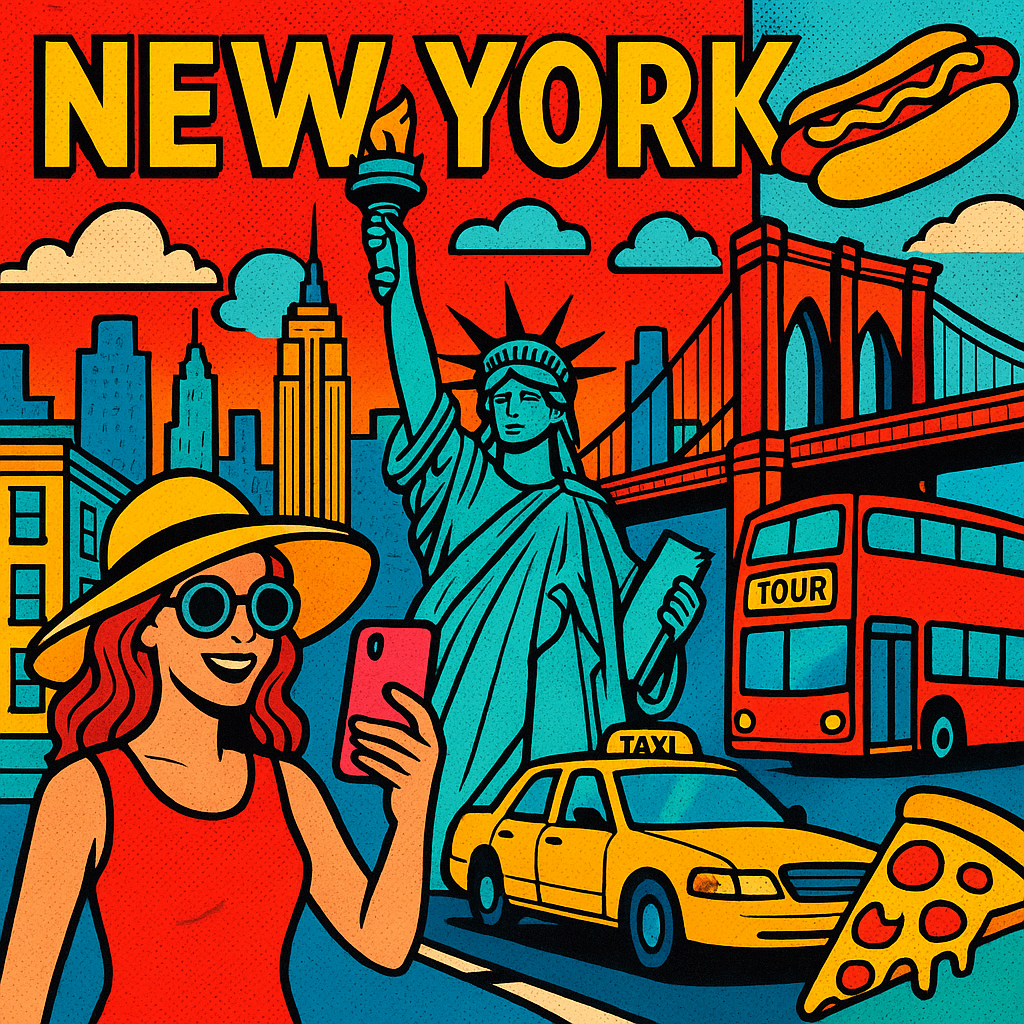

In [15]:
image = artist("New York City")
display(image)

In [16]:
def talker(message):
    response = openai.audio.speech.create(
      model="gpt-4o-mini-tts",
      voice="onyx",    # Also, try replacing onyx with alloy or coral
      input=message
    )
    return response.content

### Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow

In [17]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

In [18]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL_GPT, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL_GPT, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image

In [ ]:
def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("", ""))

/var/folders/1c/cw3ywf5x497g197n63s4g4cm0000gn/T/ipykernel_18423/3307153219.py:8: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=500, type="messages")


* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for Italy
